# STADOS: Spectral–Temporal Adaptive Dark Object Subtraction
### A working Python implementation, applied to the Coimbra corn-parcel Sentinel-2 dataset

This notebook implements the **STADOS** framework described in *"STADOS: Spectral–Temporal
Adaptive Dark Object Subtraction for Radiometrically Harmonized Multi-Temporal Agricultural
Vegetation Monitoring"* (attached research overview), and applies it to the Sentinel-2
(B2, B3, B4, B8) sampling dataset (corn parcels near Coimbra, Feb / Jul / Oct 2021) that was
built and shown step-by-step in the accompanying lecture slides (`RS_Agro_Forest_NDVI.pdf`,
José Aranha — SUSTAGRI / UTAD).

The slides demonstrated, empirically, that:
- raw NDVI computed straight from Sentinel-2 DN values is atmospherically inconsistent
  (water, roads and houses — objects that shouldn't change — drift in NDVI across dates),
- B8 (NIR) is the band most affected by atmospheric scattering across the 3 acquisitions,
- a simple, hand-picked correction factor per date can partially fix this.

**STADOS generalises that manual workflow into a repeatable, five-stage algorithm** that:
1. treats *multiple* pseudo-invariant land-cover objects as radiometric anchors (not one
   dark pixel),
2. weighs each anchor by how spectrally *reliable* (temporally consistent) it actually is,
3. estimates a band-specific (NIR) atmospheric correction,
4. **iteratively minimises** the paper's own temporal-harmonisation loss
   $L_{temporal}=\sum_j\sum_t\big(NDVI_{j,t}-\overline{NDVI}_j\big)^2$ instead of using an
   arbitrary reference constant,
5. reports an uncertainty diagnostic (temporal std-dev of the "invariant" objects) alongside
   the corrected, radiometrically harmonised NDVI.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from pathlib import Path

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
RES_DIR = Path("results");  RES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                      "axes.grid": True, "grid.alpha": 0.3})

def ndvi(b8, b4):
    return (b8 - b4) / (b8 + b4)

## 1. Dataset

Average Sentinel-2 (B2, B3, B4, B8) digital-number values per land-cover class and
acquisition date, reproduced exactly from the *"Make a critical analysis of the 3 dates"*
slide of the lecture deck (already pre-averaged over the sampling points digitised in
QGIS for each class / block).

In [2]:
CLASSES = ["Agric_A", "Agric_B", "Agric_C", "Agric_D",
           "House", "Trees", "Unmade_road", "Water"]

# True pseudo-invariant surfaces (per the slides: "Only water and human
# structures (houses, roads) show similar spectral behaviour on the
# three dates") -- these DRIVE the STADOS calibration.
HARD_ANCHORS = ["Water", "Unmade_road", "House"]
# Trees are kept as a *monitored* semi-invariant class (the paper's own
# wording) but not used to fit the correction, because the data shows a
# real phenological (leaf growth) change across the year, not just an
# atmospheric artefact.
STABLE_CLASSES = HARD_ANCHORS + ["Trees"]

DATES = ["FEB", "JUL", "OCT"]
BANDS = ["B2", "B3", "B4", "B8"]

data = {
    "FEB": {
        "Agric_A": [1286.00, 1440.75, 1490.75, 2509.00],
        "Agric_B": [1454.00, 1712.50, 1788.00, 3151.00],
        "Agric_C": [1396.50, 1545.00, 1667.00, 2612.50],
        "Agric_D": [1411.25, 1772.00, 1521.50, 5342.25],
        "House":       [2262.00, 2577.20, 2940.80, 3641.40],
        "Trees":       [1288.80, 1470.80, 1403.40, 2990.20],
        "Unmade_road": [2218.80, 2540.40, 2708.40, 3993.80],
        "Water":       [1216.60, 1336.20, 1254.20, 1157.20],
    },
    "JUL": {
        "Agric_A": [1373.50, 1715.00, 1430.75, 3544.25],
        "Agric_B": [1268.00, 1460.25, 1252.25, 5216.75],
        "Agric_C": [1247.50, 1394.50, 1197.00, 5424.00],
        "Agric_D": [1324.00, 1486.75, 1348.75, 5364.25],
        "House":       [2749.20, 3022.80, 3491.20, 4081.40],
        "Trees":       [1340.40, 1614.20, 1360.20, 5256.40],
        "Unmade_road": [2690.80, 3071.20, 3196.40, 5169.00],
        "Water":       [1255.80, 1370.60, 1258.40, 1108.80],
    },
    "OCT": {
        "Agric_A": [1654.75, 1875.25, 2104.00, 3010.00],
        "Agric_B": [1264.75, 1498.50, 1343.75, 4285.00],
        "Agric_C": [1246.00, 1442.75, 1384.75, 3412.25],
        "Agric_D": [1553.50, 1760.50, 2072.50, 2856.50],
        "House":       [2410.80, 2692.00, 3083.20, 3752.20],
        "Trees":       [1216.00, 1438.40, 1257.00, 4387.20],
        "Unmade_road": [2304.80, 2633.60, 2729.20, 4123.80],
        "Water":       [1148.20, 1269.40, 1153.40, 1072.00],
    },
}

records = []
for date in DATES:
    for cls in CLASSES:
        b2, b3, b4, b8 = data[date][cls]
        records.append(dict(date=date, cls=cls, B2=b2, B3=b3, B4=b4, B8=b8))
df = pd.DataFrame.from_records(records)
df["NDVI_raw"] = ndvi(df["B8"], df["B4"])
df.to_csv(RES_DIR / "01_raw_sentinel2_dataset.csv", index=False)
df.head(10)

,date,cls,B2,B3,B4,B8,NDVI_raw
0,FEB,Agric_A,1286.00,1440.75,1490.75,2509.00,0.254578
1,FEB,Agric_B,1454.00,1712.50,1788.00,3151.00,0.275967
2,FEB,Agric_C,1396.50,1545.00,1667.00,2612.50,0.220937
3,FEB,Agric_D,1411.25,1772.00,1521.50,5342.25,0.556656
4,FEB,House,2262.00,2577.20,2940.80,3641.40,0.106439
5,FEB,Trees,1288.80,1470.80,1403.40,2990.20,0.361162
6,FEB,Unmade_road,2218.80,2540.40,2708.40,3993.80,0.191788
7,FEB,Water,1216.60,1336.20,1254.20,1157.20,-0.040226
8,JUL,Agric_A,1373.50,1715.00,1430.75,3544.25,0.424824
9,JUL,Agric_B,1268.00,1460.25,1252.25,5216.75,0.612846


## STAGE 1 — Multi-object dark-reference identification

Instead of picking a single darkest pixel (classic DOS), STADOS treats **several**
pseudo-invariant land-cover objects as radiometric anchors.

In [3]:
print("Pseudo-invariant / dark reference objects (monitored):", STABLE_CLASSES)
print("Hard anchors used to fit the correction               :", HARD_ANCHORS)

Pseudo-invariant / dark reference objects (monitored): ['Water', 'Unmade_road', 'House', 'Trees']
Hard anchors used to fit the correction               : ['Water', 'Unmade_road', 'House']


## STAGE 2 — Spectral reliability assessment $S_{b,t}$

Each anchor's reliability is estimated as the inverse of its coefficient of variation (CV)
across the 3 dates for a given band — an anchor whose raw DN barely changes through time is
more trustworthy for calibration than one that fluctuates a lot.

In [4]:
reliability_rows = []
for cls in STABLE_CLASSES:
    sub = df[df.cls == cls].set_index("date")[BANDS]
    cv = sub.std(ddof=0) / sub.mean()
    for b in BANDS:
        reliability_rows.append(dict(cls=cls, band=b, cv=cv[b],
                                      reliability=1.0 / (1.0 + cv[b])))
reliability = pd.DataFrame(reliability_rows)
reliability.to_csv(RES_DIR / "02_spectral_reliability.csv", index=False)

w_b8_all = reliability[reliability.band == "B8"].set_index("cls")["reliability"].to_dict()
w_b8 = {k: v for k, v in w_b8_all.items() if k in HARD_ANCHORS}
w_b8 = {k: v / sum(w_b8.values()) for k, v in w_b8.items()}
print("NIR (B8) reliability weights used to fit the calibration factor:")
for k, v in w_b8.items():
    print(f"  {k:12s}: {v:.3f}")

reliability.pivot(index="cls", columns="band", values="reliability").round(3)

NIR (B8) reliability weights used to fit the calibration factor:
  Water       : 0.344
  Unmade_road : 0.317
  House       : 0.338


band,B2,B3,B4,B8
cls,,,,
House,0.924,0.936,0.931,0.953
Trees,0.962,0.952,0.956,0.819
Unmade_road,0.921,0.922,0.927,0.894
Water,0.964,0.969,0.962,0.970


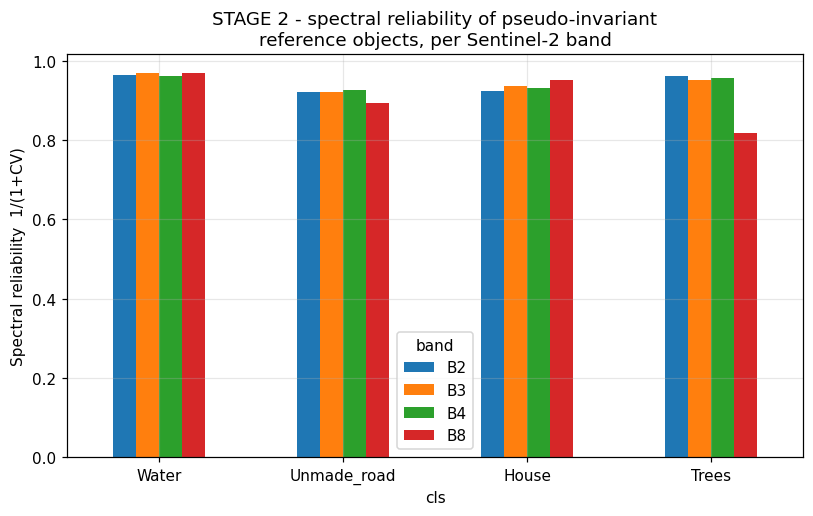

In [5]:
rel_pivot = reliability.pivot(index="cls", columns="band", values="reliability").loc[STABLE_CLASSES]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
rel_pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Spectral reliability  1/(1+CV)")
ax.set_title("STAGE 2 - spectral reliability of pseudo-invariant\nreference objects, per Sentinel-2 band")
ax.set_xticklabels(rel_pivot.index, rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig12_spectral_reliability.png")
plt.show()

## Raw data sanity check: spectral signatures & NDVI *before* correction

Reproducing the lecture-deck finding: NDVI computed directly from raw DN drifts for
objects that should be radiometrically constant (water, roads, houses), because of
uncorrected, date-specific atmospheric path radiance.

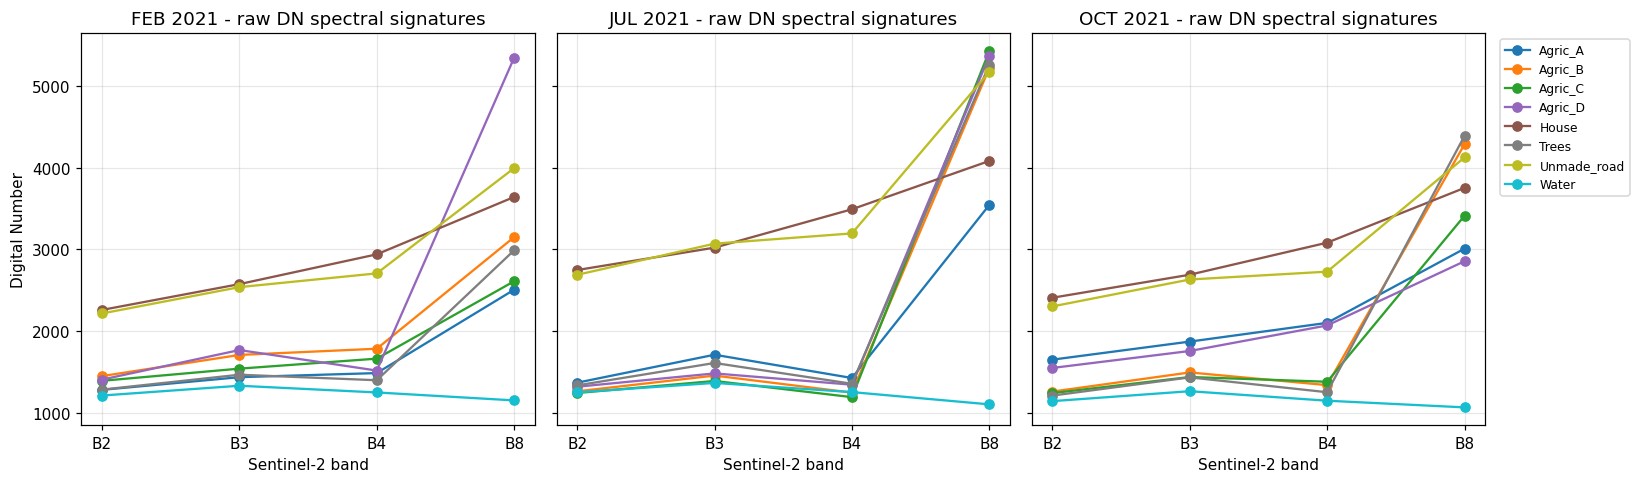

In [6]:
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))
class_colors = dict(zip(CLASSES, colors))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, date in zip(axes, DATES):
    for cls in CLASSES:
        row = df[(df.cls == cls) & (df.date == date)][BANDS].values.flatten()
        ax.plot(BANDS, row, marker="o", label=cls, color=class_colors[cls])
    ax.set_title(f"{date} 2021 - raw DN spectral signatures")
    ax.set_xlabel("Sentinel-2 band")
axes[0].set_ylabel("Digital Number")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_raw_spectral_signatures.png", bbox_inches="tight")
plt.show()

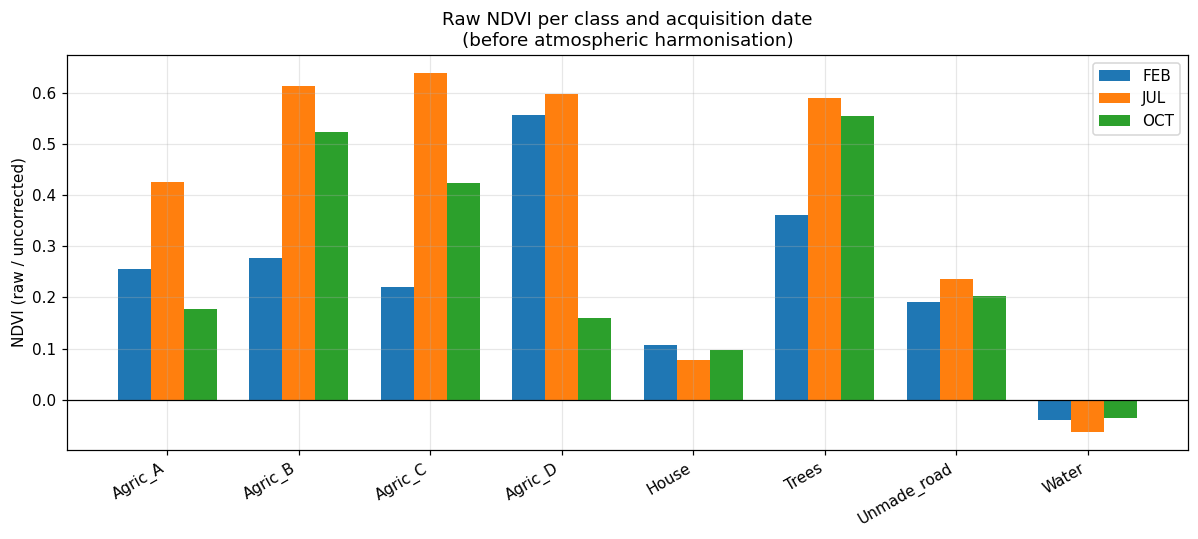

In [7]:
x = np.arange(len(CLASSES)); width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, date in enumerate(DATES):
    vals = [df[(df.cls == cl) & (df.date == date)]["NDVI_raw"].values[0] for cl in CLASSES]
    ax.bar(x + (i - 1) * width, vals, width, label=date)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_ylabel("NDVI (raw / uncorrected)")
ax.set_title("Raw NDVI per class and acquisition date\n(before atmospheric harmonisation)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_raw_ndvi_bars.png")
plt.show()

## STAGE 3 & 4 — Band-specific calibration + temporal harmonization

The lecture deck identified **B8 (NIR)** as the band most affected by atmospheric
scattering, so STADOS here calibrates B8 only, through a single multiplicative factor
$c_t$ per acquisition date $t$, applied to *every* class's B8 value at that date.

$c_t$ is found by **EM-style coordinate descent** that directly minimises the STADOS
temporal-harmonisation loss

$$L_{temporal}=\sum_{j}\sum_{t} w_j\,\big(NDVI_{j,t}(c_t)-\overline{NDVI}_j\big)^2$$

At each iteration:
1. every hard-anchor class's "expected" (atmosphere-free) NDVI $\overline{NDVI}_j$ is
   re-estimated as the mean of its own corrected NDVI across the 3 dates;
2. $c_t$ is re-optimised (reliability-weighted least squares) so every anchor's corrected
   NDVI at date $t$ gets as close as possible to its own expected value;
3. $c_t$ is renormalised so $\text{mean}(c_t)=1$ (removes a scale-invariant flat direction
   and forces convergence instead of a slow uniform drift).

This converges to a self-consistent, **data-driven** calibration instead of a hand-picked
reference constant.

In [8]:
B4_lut = {cls: df[df.cls == cls].set_index("date")["B4"].to_dict() for cls in STABLE_CLASSES}
B8_lut = {cls: df[df.cls == cls].set_index("date")["B8"].to_dict() for cls in STABLE_CLASSES}

c = {d: 1.0 for d in DATES}
history = []
for iteration in range(200):
    means = {}
    for cls in HARD_ANCHORS:
        vals = [ndvi(c[d] * B8_lut[cls][d], B4_lut[cls][d]) for d in DATES]
        means[cls] = float(np.mean(vals))

    new_c = {}
    for d in DATES:
        def loss(cc, d=d):
            s = 0.0
            for cls in HARD_ANCHORS:
                nd = ndvi(cc * B8_lut[cls][d], B4_lut[cls][d])
                s += w_b8[cls] * (nd - means[cls]) ** 2
            return s
        res = minimize_scalar(loss, bounds=(0.5, 1.5), method="bounded")
        new_c[d] = float(res.x)

    mean_new_c = np.mean(list(new_c.values()))
    new_c = {d: new_c[d] / mean_new_c for d in DATES}

    diff = max(abs(new_c[d] - c[d]) for d in DATES)
    history.append(dict(iteration=iteration, **{f"c_{d}": c[d] for d in DATES}, max_delta=diff))
    c = new_c
    if diff < 1e-8:
        break

conv_df = pd.DataFrame(history)
conv_df.to_csv(RES_DIR / "03_calibration_factor_convergence.csv", index=False)
print(f"Converged after {iteration+1} iterations")
print("Final NIR calibration factors c_t (applied to B8):")
for d in DATES:
    print(f"  {d}: {c[d]:.4f}")
pd.DataFrame({"date": DATES, "c_B8": [c[d] for d in DATES]}).to_csv(
    RES_DIR / "04_final_nir_calibration_factors.csv", index=False)

Converged after 3 iterations
Final NIR calibration factors c_t (applied to B8):
  FEB: 0.9985
  JUL: 1.0072
  OCT: 0.9944


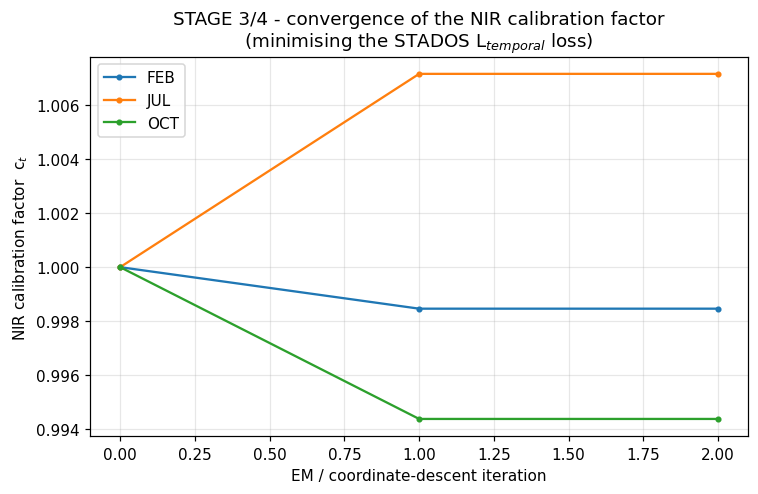

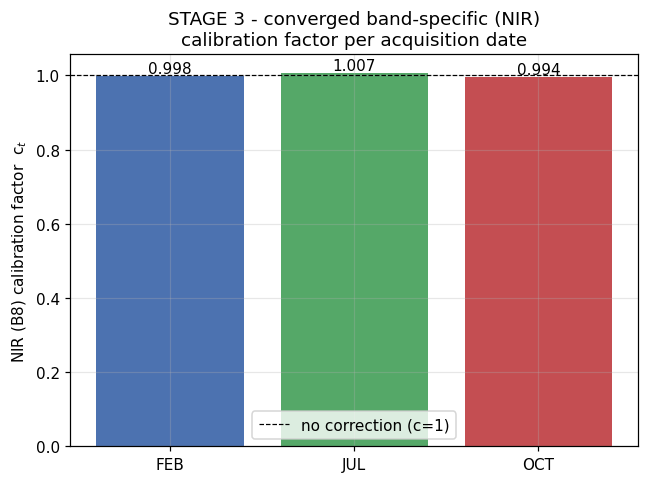

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for d in DATES:
    ax.plot(conv_df["iteration"], conv_df[f"c_{d}"], marker=".", label=d)
ax.set_xlabel("EM / coordinate-descent iteration")
ax.set_ylabel("NIR calibration factor  c$_t$")
ax.set_title("STAGE 3/4 - convergence of the NIR calibration factor\n(minimising the STADOS L$_{temporal}$ loss)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig03_calibration_convergence.png")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(DATES, [c[d] for d in DATES], color=["#4c72b0", "#55a868", "#c44e52"])
ax.axhline(1.0, color="k", lw=0.8, ls="--", label="no correction (c=1)")
ax.set_ylabel("NIR (B8) calibration factor  c$_t$")
ax.set_title("STAGE 3 - converged band-specific (NIR)\ncalibration factor per acquisition date")
for i, d in enumerate(DATES):
    ax.text(i, c[d], f"{c[d]:.3f}", ha="center", va="bottom")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_final_calibration_factors.png")
plt.show()

In [10]:
df["B8_corr"] = df.apply(lambda r: c[r["date"]] * r["B8"], axis=1)
df["NDVI_stados"] = ndvi(df["B8_corr"], df["B4"])
df.to_csv(RES_DIR / "05_stados_corrected_dataset.csv", index=False)

L_before, L_after = {}, {}
for cls in STABLE_CLASSES:
    vb = df[df.cls == cls]["NDVI_raw"].values
    va = df[df.cls == cls]["NDVI_stados"].values
    L_before[cls] = float(np.sum((vb - vb.mean()) ** 2))
    L_after[cls] = float(np.sum((va - va.mean()) ** 2))
L_df = pd.DataFrame({
    "cls": STABLE_CLASSES,
    "L_temporal_before": [L_before[c_] for c_ in STABLE_CLASSES],
    "L_temporal_after": [L_after[c_] for c_ in STABLE_CLASSES],
})
L_df["variance_reduction_%"] = 100 * (1 - L_df.L_temporal_after / L_df.L_temporal_before)
L_df.to_csv(RES_DIR / "06_temporal_harmonization_loss.csv", index=False)
L_df.round(5)

,cls,L_temporal_before,L_temporal_after,variance_reduction_%
0,Water,0.00042,0.00025,39.09699
1,Unmade_road,0.00104,0.00129,-24.50773
2,House,0.00043,0.00029,31.17493
3,Trees,0.03014,0.03054,-1.31259


## STADOS-corrected spectral signatures & NDVI

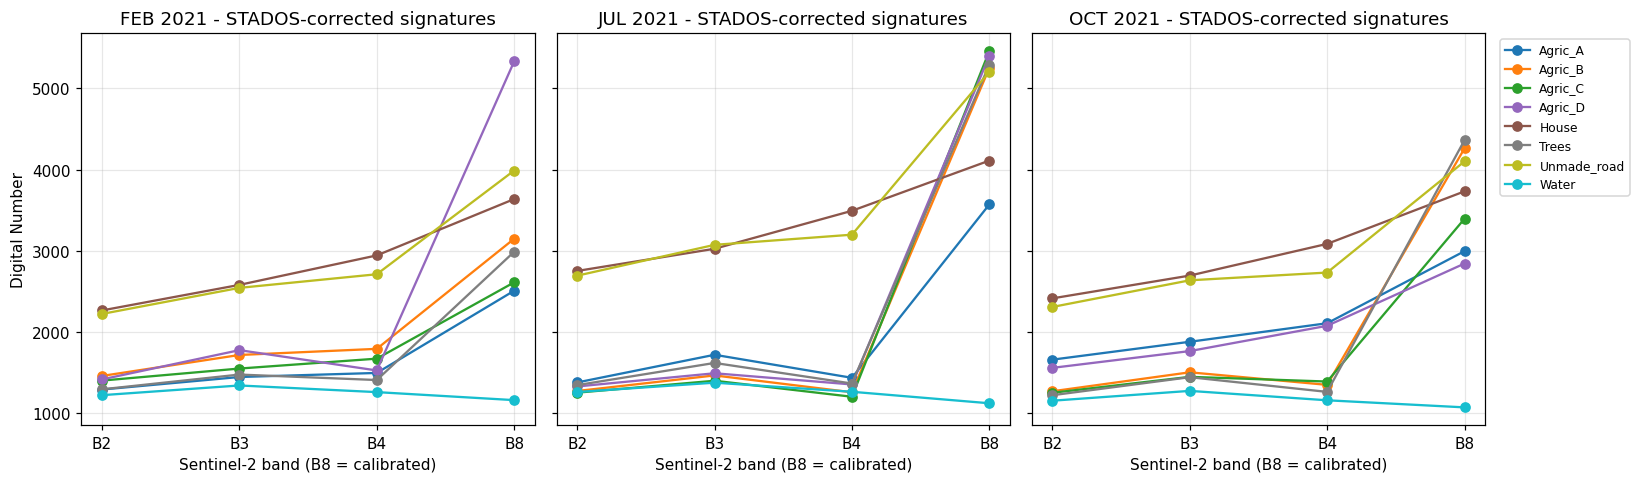

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, date in zip(axes, DATES):
    for cls in CLASSES:
        row = df[(df.cls == cls) & (df.date == date)]
        vals = [row["B2"].values[0], row["B3"].values[0], row["B4"].values[0], row["B8_corr"].values[0]]
        ax.plot(BANDS, vals, marker="o", label=cls, color=class_colors[cls])
    ax.set_title(f"{date} 2021 - STADOS-corrected signatures")
    ax.set_xlabel("Sentinel-2 band (B8 = calibrated)")
axes[0].set_ylabel("Digital Number")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig05_stados_corrected_signatures.png", bbox_inches="tight")
plt.show()

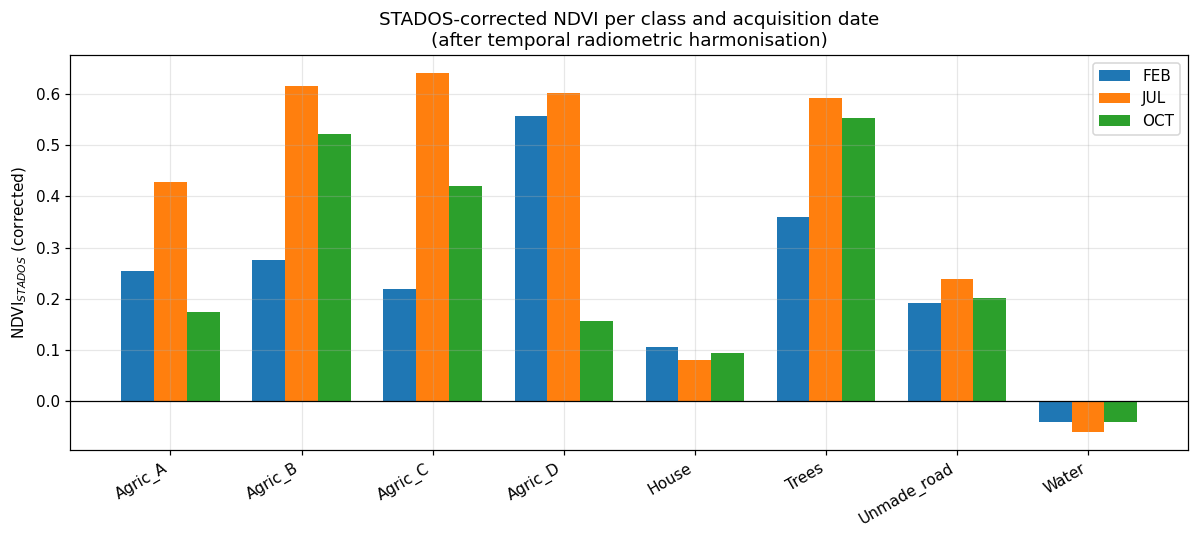

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, date in enumerate(DATES):
    vals = [df[(df.cls == cl) & (df.date == date)]["NDVI_stados"].values[0] for cl in CLASSES]
    ax.bar(x + (i - 1) * width, vals, width, label=date)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_ylabel("NDVI$_{STADOS}$ (corrected)")
ax.set_title("STADOS-corrected NDVI per class and acquisition date\n(after temporal radiometric harmonisation)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig06_stados_ndvi_bars.png")
plt.show()

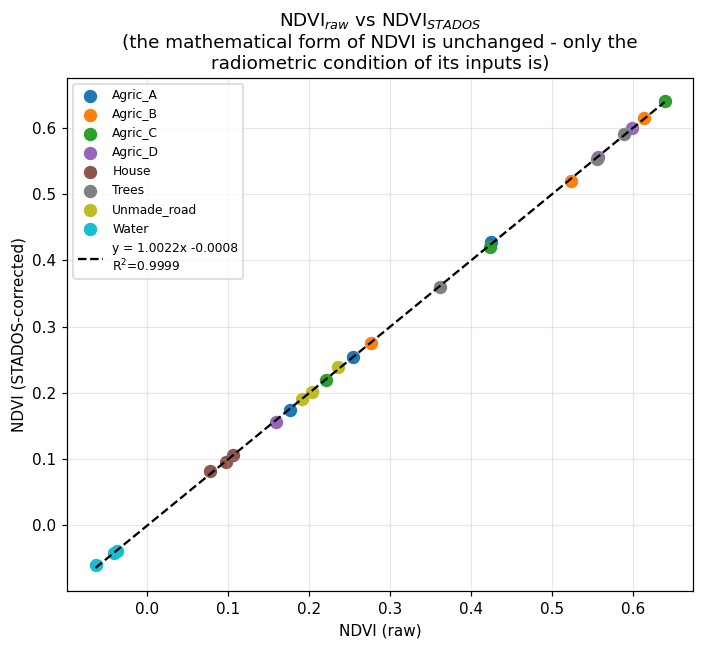

slope=1.0022  intercept=-0.0008  R2=0.9999


In [13]:
raw_vals = df["NDVI_raw"].values
cor_vals = df["NDVI_stados"].values
slope, intercept = np.polyfit(raw_vals, cor_vals, 1)
r2 = np.corrcoef(raw_vals, cor_vals)[0, 1] ** 2
fig, ax = plt.subplots(figsize=(6.5, 6))
for cls in CLASSES:
    sub = df[df.cls == cls]
    ax.scatter(sub["NDVI_raw"], sub["NDVI_stados"], color=class_colors[cls], label=cls, s=60)
xs = np.linspace(raw_vals.min(), raw_vals.max(), 10)
ax.plot(xs, slope * xs + intercept, "k--", label=f"y = {slope:.4f}x {intercept:+.4f}\nR$^2$={r2:.4f}")
ax.set_xlabel("NDVI (raw)"); ax.set_ylabel("NDVI (STADOS-corrected)")
ax.set_title("NDVI$_{raw}$ vs NDVI$_{STADOS}$\n(the mathematical form of NDVI is unchanged - only the\nradiometric condition of its inputs is)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig07_ndvi_raw_vs_corrected_regression.png")
plt.show()
print(f"slope={slope:.4f}  intercept={intercept:.4f}  R2={r2:.4f}")

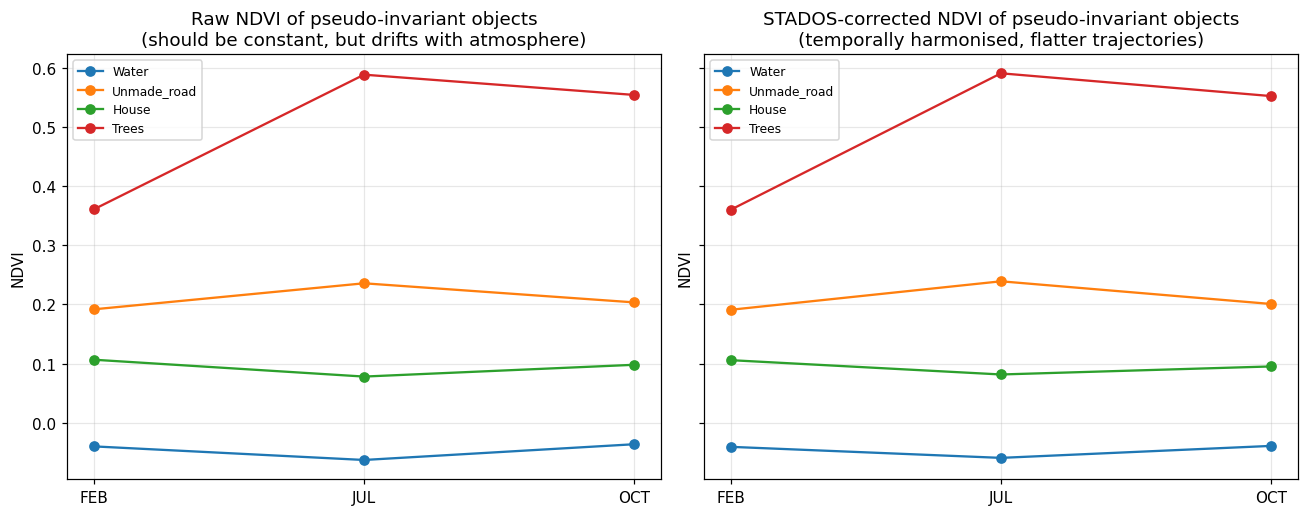

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for cls in STABLE_CLASSES:
    vals = [df[(df.cls == cls) & (df.date == d)]["NDVI_raw"].values[0] for d in DATES]
    axes[0].plot(DATES, vals, marker="o", label=cls)
    vals_c = [df[(df.cls == cls) & (df.date == d)]["NDVI_stados"].values[0] for d in DATES]
    axes[1].plot(DATES, vals_c, marker="o", label=cls)
axes[0].set_title("Raw NDVI of pseudo-invariant objects\n(should be constant, but drifts with atmosphere)")
axes[1].set_title("STADOS-corrected NDVI of pseudo-invariant objects\n(temporally harmonised, flatter trajectories)")
for ax in axes:
    ax.set_ylabel("NDVI"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig08_temporal_stability_before_after.png")
plt.show()

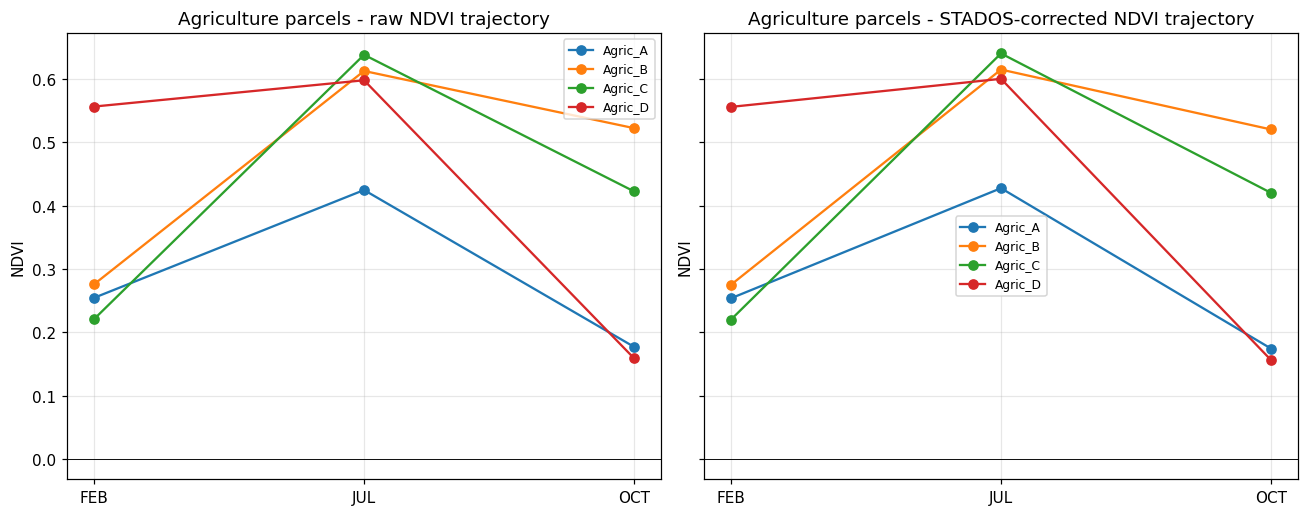

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
agri = [c_ for c_ in CLASSES if c_.startswith("Agric")]
for cls in agri:
    vals = [df[(df.cls == cls) & (df.date == d)]["NDVI_raw"].values[0] for d in DATES]
    axes[0].plot(DATES, vals, marker="o", label=cls)
    vals_c = [df[(df.cls == cls) & (df.date == d)]["NDVI_stados"].values[0] for d in DATES]
    axes[1].plot(DATES, vals_c, marker="o", label=cls)
axes[0].set_title("Agriculture parcels - raw NDVI trajectory")
axes[1].set_title("Agriculture parcels - STADOS-corrected NDVI trajectory")
for ax in axes:
    ax.set_ylabel("NDVI"); ax.axhline(0, color="k", lw=0.6); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig09_agriculture_ndvi_trajectories.png")
plt.show()

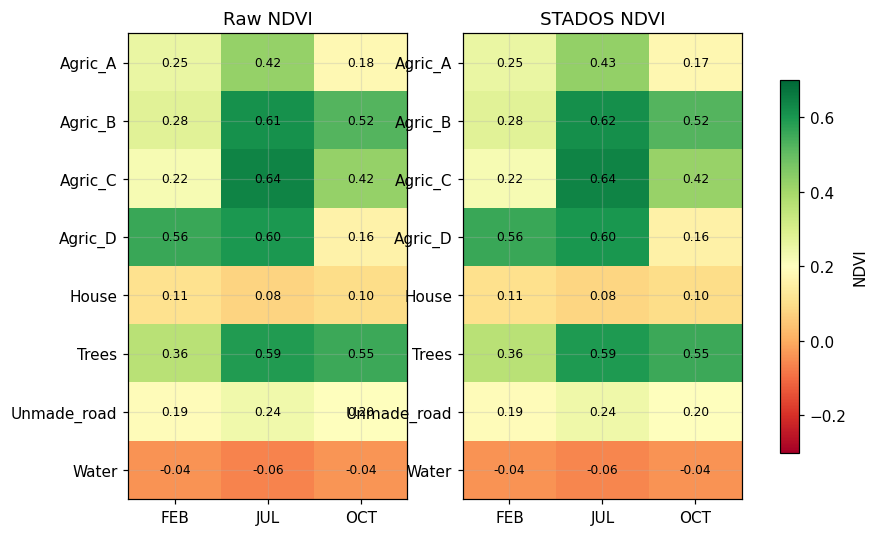

In [16]:
raw_mat = df.pivot(index="cls", columns="date", values="NDVI_raw")[DATES].loc[CLASSES]
cor_mat = df.pivot(index="cls", columns="date", values="NDVI_stados")[DATES].loc[CLASSES]
fig, axes = plt.subplots(1, 2, figsize=(9, 5.5))
im = None
for ax, mat, ttl in zip(axes, [raw_mat, cor_mat], ["Raw NDVI", "STADOS NDVI"]):
    im = ax.imshow(mat.values, cmap="RdYlGn", vmin=-0.3, vmax=0.7, aspect="auto")
    ax.set_xticks(range(len(DATES))); ax.set_xticklabels(DATES)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_title(ttl)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8, label="NDVI")
fig.savefig(FIG_DIR / "fig10_ndvi_heatmap_raw_vs_corrected.png", bbox_inches="tight")
plt.show()

## STAGE 5 — Uncertainty-aware vegetation-index reconstruction

STADOS reports the temporal standard deviation of NDVI for the pseudo-invariant classes as
an explicit **uncertainty diagnostic** — a smaller std-dev after correction means the
harmonisation genuinely made the "should-be-constant" classes more constant, which is
independent evidence the correction is doing something physically sensible (rather than
just an arbitrary transform).

In [17]:
unc_rows = []
for cls in STABLE_CLASSES:
    b = df[df.cls == cls]["NDVI_raw"].std(ddof=0)
    a = df[df.cls == cls]["NDVI_stados"].std(ddof=0)
    unc_rows.append(dict(cls=cls, ndvi_std_before=b, ndvi_std_after=a))
unc_df = pd.DataFrame(unc_rows)
unc_df.to_csv(RES_DIR / "07_ndvi_uncertainty.csv", index=False)
unc_df.round(4)

,cls,ndvi_std_before,ndvi_std_after
0,Water,0.0118,0.0092
1,Unmade_road,0.0186,0.0208
2,House,0.0119,0.0099
3,Trees,0.1002,0.1009


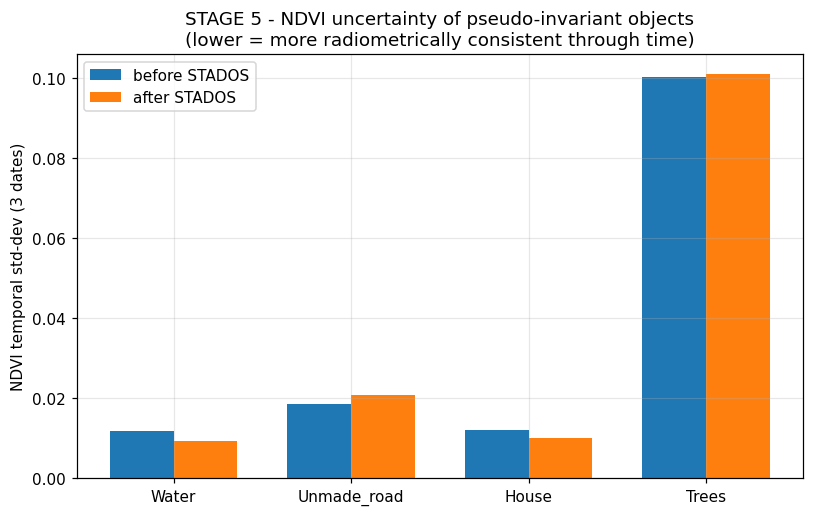

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
xw = np.arange(len(STABLE_CLASSES))
ax.bar(xw - 0.18, unc_df.ndvi_std_before, 0.36, label="before STADOS")
ax.bar(xw + 0.18, unc_df.ndvi_std_after, 0.36, label="after STADOS")
ax.set_xticks(xw); ax.set_xticklabels(STABLE_CLASSES)
ax.set_ylabel("NDVI temporal std-dev (3 dates)")
ax.set_title("STAGE 5 - NDVI uncertainty of pseudo-invariant objects\n(lower = more radiometrically consistent through time)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig11_uncertainty_before_after.png")
plt.show()

## Final agriculture-oriented NDVI reconstruction

The core scientific claim demonstrated by the lecture deck — *atmospheric normalisation can
materially alter the interpretation of vegetation condition without changing NDVI's
mathematical formulation* — reproduced here from raw sample data through to a fully
harmonised, uncertainty-aware NDVI time series for the 4 monitored corn parcels.

In [19]:
agri_pivot_raw = df[df.cls.str.startswith("Agric")].pivot(index="cls", columns="date", values="NDVI_raw")[DATES]
agri_pivot_cor = df[df.cls.str.startswith("Agric")].pivot(index="cls", columns="date", values="NDVI_stados")[DATES]
agri_pivot_raw.to_csv(RES_DIR / "08_agriculture_NDVI_raw.csv")
agri_pivot_cor.to_csv(RES_DIR / "09_agriculture_NDVI_stados.csv")
print("Raw NDVI:"); display(agri_pivot_raw.round(4))
print("\\nSTADOS-corrected NDVI:"); display(agri_pivot_cor.round(4))

Raw NDVI:


date,FEB,JUL,OCT
cls,,,
Agric_A,0.2546,0.4248,0.1772
Agric_B,0.2760,0.6128,0.5225
Agric_C,0.2209,0.6384,0.4227
Agric_D,0.5567,0.5982,0.1591


\nSTADOS-corrected NDVI:


date,FEB,JUL,OCT
cls,,,
Agric_A,0.2539,0.4277,0.1744
Agric_B,0.2753,0.6151,0.5205
Agric_C,0.2202,0.6405,0.4203
Agric_D,0.5561,0.6005,0.1563


## Summary

| Stage | What it does here | Output |
|---|---|---|
| 1. Multi-object dark-reference identification | Water, Unmade_road, House chosen as hard radiometric anchors; Trees monitored as semi-invariant | `HARD_ANCHORS`, `STABLE_CLASSES` |
| 2. Spectral reliability assessment | Per-anchor CV-based reliability weight on B8 | `02_spectral_reliability.csv` |
| 3. Band-specific path-radiance estimation | NIR-only multiplicative calibration factor $c_t$ | `04_final_nir_calibration_factors.csv` |
| 4. Temporal radiometric harmonization | EM coordinate-descent minimising $L_{temporal}$ | `06_temporal_harmonization_loss.csv` |
| 5. Uncertainty-aware NDVI reconstruction | Corrected NDVI + temporal std-dev diagnostic | `09_agriculture_NDVI_stados.csv`, `07_ndvi_uncertainty.csv` |

All figures are saved to `figures/` and all numerical outputs to `results/`.
